# SGD and Regression on Diabetes database
The structure of this notebook reflects the implementation of SGD and linear regression from scratch in Python as of ```Friday, March 13, 2026``` in this repository.
## Gradient Descent
1. Develop Numerical Differentiation.
2. Extend to multivariable case for calculating gradients
3. Define an iterative algorithm for gradient descent.

In [1]:
import numpy as np
import random as rnd

### Numerical differentiation
- Using standard LHL-RHL definition of limits, then averaging for better stability. Can do with multiple sample points like $x_0-2h,x_0-h,x_0,x_0+h,x_0+2h$, but not strictly necessary for the moment.
- This assumes that the function we provide will be differentiable at the point in question.

In [2]:
def numerical_derivative(f, x, axis, diff_step = 1e-5):
    if axis >= x.shape[0] :
        raise IndexError(f"Can't differentiate wrt x_{axis+1} when x has shape {x.shape}")
    else :
        basis_vector = np.zeros_like(x)
        basis_vector[axis] = diff_step

        left = (f(x) - f(x - basis_vector))/diff_step

        right = (f(x + basis_vector) - f(x))/diff_step

        return 0.5 * (left + right)

#-------------------------------------------------------------------------------------------------

### Gradient
- Simply performing numerical differentiation along different axes/coordinates.

In [3]:
# Takes a function and a point
# Returns an array (same shape as input vector) containing partial derivatives evaluated at the point
def grad(f, x) :
    gg = np.zeros(x.shape)
    # print(f"x has length {gg.shape[0]}")
    for i in range(x.shape[0]) :
        gg[i] = numerical_derivative(f, x, i)
        # print(f"using partial deriv {numerical_derivative(f, x, i)}")
    return gg

#-------------------------------------------------------------------------------------------------


### Gradient Descent
- Given a (differentiable) function $f$, an initial point $x_0$, one can compute the gradient at the point, find the direction of greatest change of $x_0$ (in fact it is given precisely by the gradient), and "ascend" or "descend" in that direction.
- We stop when a certain number of iterations have been performed, quit early if gradient is small. Better stopping conditions are possible:
- example : stop when gradient is small enough (what if it takes too long?)
- example : stop when the objective value is cycling/looping/not reducing fast enough over the last $k$-iterations, for some set $k$.

In [4]:
# Takes a function, initial point, number of iterations and step size as input
# Performs gradient descent, returns an estimate of a local arg_min(f), given the starting point.
def gd(f, init_x, step_size : float, max_iters : int = 200) :
    current_vector = init_x
    iteration = 0
    gradient = np.ones(init_x.shape)
    while iteration < max_iters and np.sum(gradient**2) > 1e-4:
        gradient = grad(f, current_vector)
        # gradient /= np.sum(gradient**2)
        current_vector = current_vector - step_size * gradient
        iteration += 1
    return current_vector

#-------------------------------------------------------------------------------------------------

## Stochastic Gradient Descent
Given a function that depends on some data (separate from the optimizing parameter), we can either optimize the whole function with the complete data. Alternatively, we use sub-samples to define a restricted version of the whole function, and optimize it using gradient descent. In particular, we choose a batch size and the number of epochs (number of times we will "learn" from the same textbook). Then :
- In each epoch, partition the complete sample into random batches of predetermined size, avoiding repetition inside the batches.
- For each batch : Make an error function (in our case, but the theory holds generally) using just the batch data.
- Minimize the batch error function for 1 (or more) iteration(s) using gradient descent.
- New batch : repeat.
- New epoch : repeat.

In [5]:
def randomizer (num_of_samples : int, batch_size : int) : # Use each epoch
    subsample = rnd.sample(range(num_of_samples), batch_size)
    return subsample

In [6]:
def ols_error_function(X,y) : # Returns a function that will take "Data", that is [X,y]
    def loss (theta) :
        return np.sum((y - X @ theta)**2) # This X will have to have an extra column of 1s.
    return loss

In [7]:
def sgd(XX, y, n_epochs : int, batch_size : int, learning_rate : float) :
    # First prepare for an added constant. Add a column of ones to X.
    X = np.concatenate((np.ones((XX.shape[0], 1), dtype=float), XX), axis=1)

    epoch = 0
    n_samples = X.shape[0]
    current_theta = np.zeros(X.shape[1])
    # Number of iterations to be used for each use of gd.
    # print("starting sgd. epoch 1, current theta is 0")
    while epoch < n_epochs :
        indices = randomizer(n_samples , batch_size)

        X_train = X[indices]
        y_train = y[indices]

        error = ols_error_function(X_train,y_train)
        # now do gradient descent :
        # print(f"epoch {epoch}, current theta is {str(current_theta)}")
        # print()

        current_theta = gd(error, current_theta, learning_rate)

        epoch = epoch + 1
    # print()
    # print(f"loop finished. theta is {str(current_theta)}")
    return current_theta # This is t_0, t_1, t_2, ..., t_n

In [8]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split


diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

print("Loaded the diabetes database from sklearn.datasets")
print()
# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Data has been split. Training on {X_train.shape[0]} samples and testing on {X_test.shape[0]} samples")
print()
print("Now beginning SGD...")

theta = sgd(X_train, y_train, 50, 150, 0.001)
print("SGD complete; will show a comparison of true-vs-predicted values now :")
print()


n_samples_to_show = 10
shuffled_indices = np.random.permutation(n_samples_to_show)
for i in shuffled_indices:
    print(y_test[i], " ----------- ", theta[0] + X_test[i]@theta[1:])


Loaded the diabetes database from sklearn.datasets

Data has been split. Training on 353 samples and testing on 89 samples

Now beginning SGD...
SGD complete; will show a comparison of true-vs-predicted values now :

242.0  -----------  253.02719121182272
84.0  -----------  94.66778922787415
111.0  -----------  122.12902527854061
70.0  -----------  183.89714024817275
219.0  -----------  140.21287626035488
230.0  -----------  292.6918228833988
202.0  -----------  141.88521106852443
96.0  -----------  111.37353662631034
272.0  -----------  187.68487238715628
94.0  -----------  86.06727309872264


### Thoughts :
Throughout the minimization process we have had faith that a minimum exists, and will be achieved. For convex loss functions such as in regression, kernel methods, etc, we know this, and SGD (with appropriate step size) does find at least a global minimum (if it exists in $\mathbb{R}$), so we are safe.
Also :
> What might be a good estimate of how many iterations of GD should be used? It has been manually set as 200, but is that optimal?

# Classifiers
- We know an iterative form for logistical regression classifiers, and can rely directly on that instead of calculating gradients as if we know nothing about the function :
- We use a randomizer to get shuffled samples of a certain batch size.
- We define the sigmoid function.

In [9]:
import numpy as np
import random as rnd


def randomizer (num_of_samples : int, batch_size : int) : # Use each epoch
    subsample = rnd.sample(range(num_of_samples), batch_size)
    return subsample



def sigmoid(z) :
    if z >= 0:
        return 1/(1 + np.exp(-z))
    return np.exp(z)/(1 + np.exp(z))


def logit_grad(X,Y, theta) :
    # assuming theta.T@X(i) makes sense, and is a real number.
    mysum = np.zeros_like(theta)
    iterator = 0
    sample_size = Y.shape[0]
    # print(theta)
    while iterator < sample_size :
        # use the known form of the gradient
        mysum = mysum + (Y[iterator] - sigmoid(theta.T @ X[iterator]))*X[iterator]
        iterator += 1
    return mysum/sample_size # scaled down.


# %%
def logit_sgd(XX, y, n_iterations : int, batch_size : int, learning_rate : float) :
    # First prepare for an added constant. Add a column of ones to X.
    X = np.concatenate((np.ones((XX.shape[0], 1), dtype=float), XX), axis=1)

    iteration = 0
    n_samples = X.shape[0]
    current_theta = np.zeros(X.shape[1])
    # Number of iterations to be used for each use of gd.
    # print("starting sgd. epoch 1, current theta is 0")
    while iteration < n_iterations :
        indices = randomizer(n_samples , batch_size)

        X_train = X[indices]
        y_train = y[indices]

        # now do gradient descent :
        # print(f"epoch {epoch}, current theta is {str(current_theta)}")
        # print()
        gradient = logit_grad(X_train, y_train, current_theta)

        current_theta = current_theta + learning_rate * gradient
        # here we do gradient ascent, because we are maximizing the MLE.

        iteration = iteration + 1
    # print()
    # print(f"loop finished. theta is {str(current_theta)}")
    return current_theta # This is t_0, t_1, t_2, ..., t_n


def predicted_probability(theta, X) :
    return sigmoid(theta[0] + theta[1:].T @ X)

def predicted_label(theta, X) :
    if predicted_probability(theta, X) > 0.5 :
        return 1
    return 0

This can be tested on the cancer database (`checking_cancer.py` file on repo), seems to perform well. Now extend to multinomial/softmax regression classifier. We are simply performing the earlier thing on various labels and picking the one with higher probability.

In [10]:
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)


def softmax_sgd(XX, y, n_iterations, batch_size, learning_rate):
    n, d = XX.shape
    X = np.concatenate((np.ones((XX.shape[0], 1), dtype=float), XX), axis=1)
    classes = np.unique(y)
    K = len(classes)

    theta = np.zeros((d+1, K))

    # 1-0 labels
    Y = np.zeros((n, K))
    Y[np.arange(n), y] = 1

    for _ in range(n_iterations):

        idx = np.random.choice(n, batch_size)
        Xb = X[idx]
        Yb = Y[idx]

        scores = Xb @ theta
        probs = softmax(scores)

        grad = Xb.T @ (probs - Yb) / batch_size

        theta -= learning_rate * grad

    return theta



def predict_softmax(X, theta):
    scores = X @ theta[1:] + theta[0]
    return np.argmax(scores, axis=1)

def predict_proba_softmax(X, theta):
    return softmax(X @ theta[1:] + theta[0])

This can be tested on the fashionmnist database as follows :

Prediction: 9
True label: 9


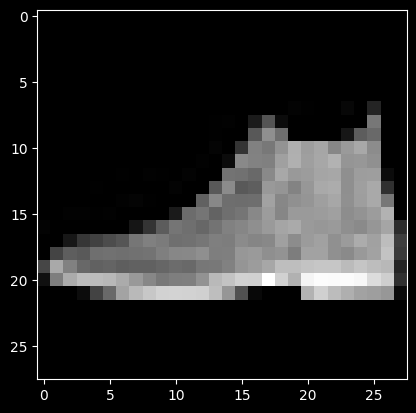

In [12]:
from torchvision import datasets
import matplotlib.pyplot as plt



train = datasets.FashionMNIST(root="data", train=True, download=True)
test  = datasets.FashionMNIST(root="data", train=False, download=True)

X_train = train.data.numpy()
y_train = train.targets.numpy()

X_test = test.data.numpy()
y_test = test.targets.numpy()

X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

X_train = X_train / 255.0
X_test = X_test / 255.0




theta = softmax_sgd(X_train, y_train, n_iterations=2000, batch_size=128, learning_rate=0.1)
y_prediction = predict_softmax(X_test, theta)



i = 0
plt.imshow(X_test[i,:].reshape(28,28), cmap="gray")
print("Prediction:", y_prediction[i])
print("True label:", y_test[i])